In [1]:
import torch
import torch.nn as nn
import numpy as np
import cv2
import matplotlib.pyplot as plt

from torchvision import models, transforms
from PIL import Image

In [25]:
import os

BASE_DIR = os.path.abspath("..")  # goes to project root

In [26]:
model_path = os.path.join(BASE_DIR, "models/classification/efficientnet_b0_best.pth")
image_path = os.path.join(BASE_DIR, "data/Testing/glioma/Te-gl_0010.jpg")
output_path = os.path.join(BASE_DIR, "outputs/gradcam.jpg")

In [2]:
device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
print(device)

mps


In [3]:
def load_densenet_model(model_path):
    
    model = models.densenet121(weights=None)
    
    # Change classifier for 4 classes
    model.classifier = nn.Linear(model.classifier.in_features, 4)
    
    model.load_state_dict(torch.load(model_path, map_location=device))
    
    model.to(device)
    model.eval()
    
    return model

In [4]:
model = load_densenet_model("../models/classification/densenet121_model.pth")
print("DenseNet loaded ✅")

DenseNet loaded ✅


In [18]:
target_layer = model.features[-2]
print("DenseNet layer selected ✅")

DenseNet layer selected ✅


In [19]:
class GradCAM:
    def __init__(self, model, target_layer):
        self.model = model
        self.target_layer = target_layer
        
        self.gradients = None
        self.activations = None
        
        self.target_layer.register_forward_hook(self.save_activation)
        self.target_layer.register_backward_hook(self.save_gradient)

    def save_activation(self, module, input, output):
        self.activations = output

    def save_gradient(self, module, grad_input, grad_output):
        self.gradients = grad_output[0]

    def generate(self, input_tensor, class_idx):
        output = self.model(input_tensor)
        self.model.zero_grad()
        
        output[0, class_idx].backward()
        
        gradients = self.gradients.cpu().data.numpy()[0]
        activations = self.activations.cpu().data.numpy()[0]
        
        weights = np.mean(gradients, axis=(1, 2))
        
        cam = np.zeros(activations.shape[1:], dtype=np.float32)
        
        for i, w in enumerate(weights):
            cam += w * activations[i]
        
        cam = np.maximum(cam, 0)
        cam = cam / np.max(cam)
        
        return cam

In [20]:
gradcam = GradCAM(model, target_layer)
print("GradCAM ready for DenseNet ✅")

GradCAM ready for DenseNet ✅


In [21]:
image_path = "../archive/Testing/glioma/Te-gl_0010.jpg"

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

image = Image.open(image_path).convert("RGB")
input_tensor = transform(image).unsqueeze(0).to(device)

print("Image loaded ✅")

Image loaded ✅


In [22]:
output = model(input_tensor)
pred_class = output.argmax(dim=1).item()

cam = gradcam.generate(input_tensor, pred_class)

print("DenseNet heatmap generated ✅")

DenseNet heatmap generated ✅


(np.float64(-0.5), np.float64(223.5), np.float64(223.5), np.float64(-0.5))

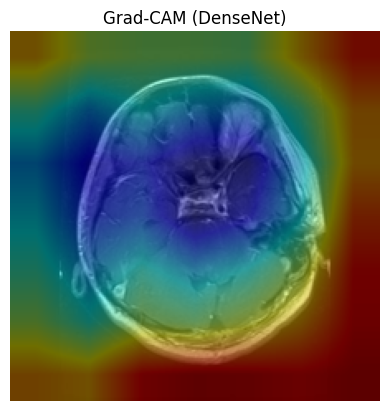

In [23]:
cam = cv2.resize(cam, (224, 224))
heatmap = cv2.applyColorMap(np.uint8(255 * cam), cv2.COLORMAP_JET)
heatmap = np.float32(heatmap) / 255

img = np.array(image.resize((224, 224)))
img = np.float32(img) / 255

overlay = heatmap * 0.4 + img * 0.6
overlay = overlay / np.max(overlay)

plt.imshow(overlay)
plt.title("Grad-CAM (DenseNet)")
plt.axis("off")

In [24]:
cv2.imwrite("densenet_gradcam.jpg", (overlay * 255).astype(np.uint8))
print("DenseNet image saved ✅")

DenseNet image saved ✅


DenseNet output shows:

🔴 Activation mostly on edges/background

🔵 Brain region mostly ignored

❌ No clear tumor focus

❌ Looks almost like a gradient/blur, not attention

---
---